# INPUT and define global VARs

In [1]:
import numpy as np
import torch
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IREE version: candidate-20230815.614

# use DCMAKE_BUILD_TYPE=RelWithDebInfo or Debug and DIREE_ENABLE_ASSERTIONS=ON


REPETITIONS_PER_LAUNCH=17
RAGDOLL_ROOT="../.."
RAGDOLL_WORKSPACE="../../build"
RAGDOLL_WORKLOADS="../../workloads"
CASE_NAME="matmul"

# TODO: add tf bench, add jax bench

# Input: Matmul (M,K,N) => (1026, 2556, 1026)

In [2]:
!cat {RAGDOLL_WORKLOADS}/common/operators/{CASE_NAME}.mlir
!{RAGDOLL_WORKSPACE}/bin/ragdoll-opt \
    {RAGDOLL_WORKLOADS}/common/operators/{CASE_NAME}.mlir \
    --pass-pipeline="builtin.module(func.func( \
    tosa-to-linalg-named \
))" > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg
!cat {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %c0 = arith.constant 0.0 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%c0 : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}



# Baseline: Default IREE codegen solution

# DIY: Configure Matmul Kernel with JIT-recipe

## Raw Benchmark Method - by python timers

## Apple-to-Apple Benchmark Comparisons
In above case, we use python builtin facilities to benchmark between pytorch, iree and ragdoll
Here, we will present how to get rid of python-side overheads that affect the accuracy of benchmarking

As discussed above we have tools for iree and utils.benchmark module for pytorch

## Do it in CPU
to compile CPU version IREE-system kernel, just change 'cuda' to 'llvm-cpu'
just like:
```shell
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb.cpu \
--iree-hal-target-backends=llvm-cpu \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH} \
--iree-llvmcpu-debug-symbols=false \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf
```

to configure optimisation strategy, you have some triggers to adjust:
```shell
--iree-llvmcpu-enable-transform-dialect-jit \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \
--iree-llvmcpu-enable-ukernels=all \
--iree-llvmcpu-slp-vectorization \
--iree-llvmcpu-number-of-threads=48 \
--iree-llvmcpu-distribution-size=96 \
```

/tmp/ipykernel_837177/1071676612.py:79: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda-12.2'
2024-03-29 12:54:43.620986: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-03-29 12:54:44.308405: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-03-29 12:54:44.308457: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-03-29 12:54:45.031420: E tensorflow/stream_executor/cuda/cuda_driver.cc:328] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capabl

Text(0.5, 0.98, 'Time Cost')

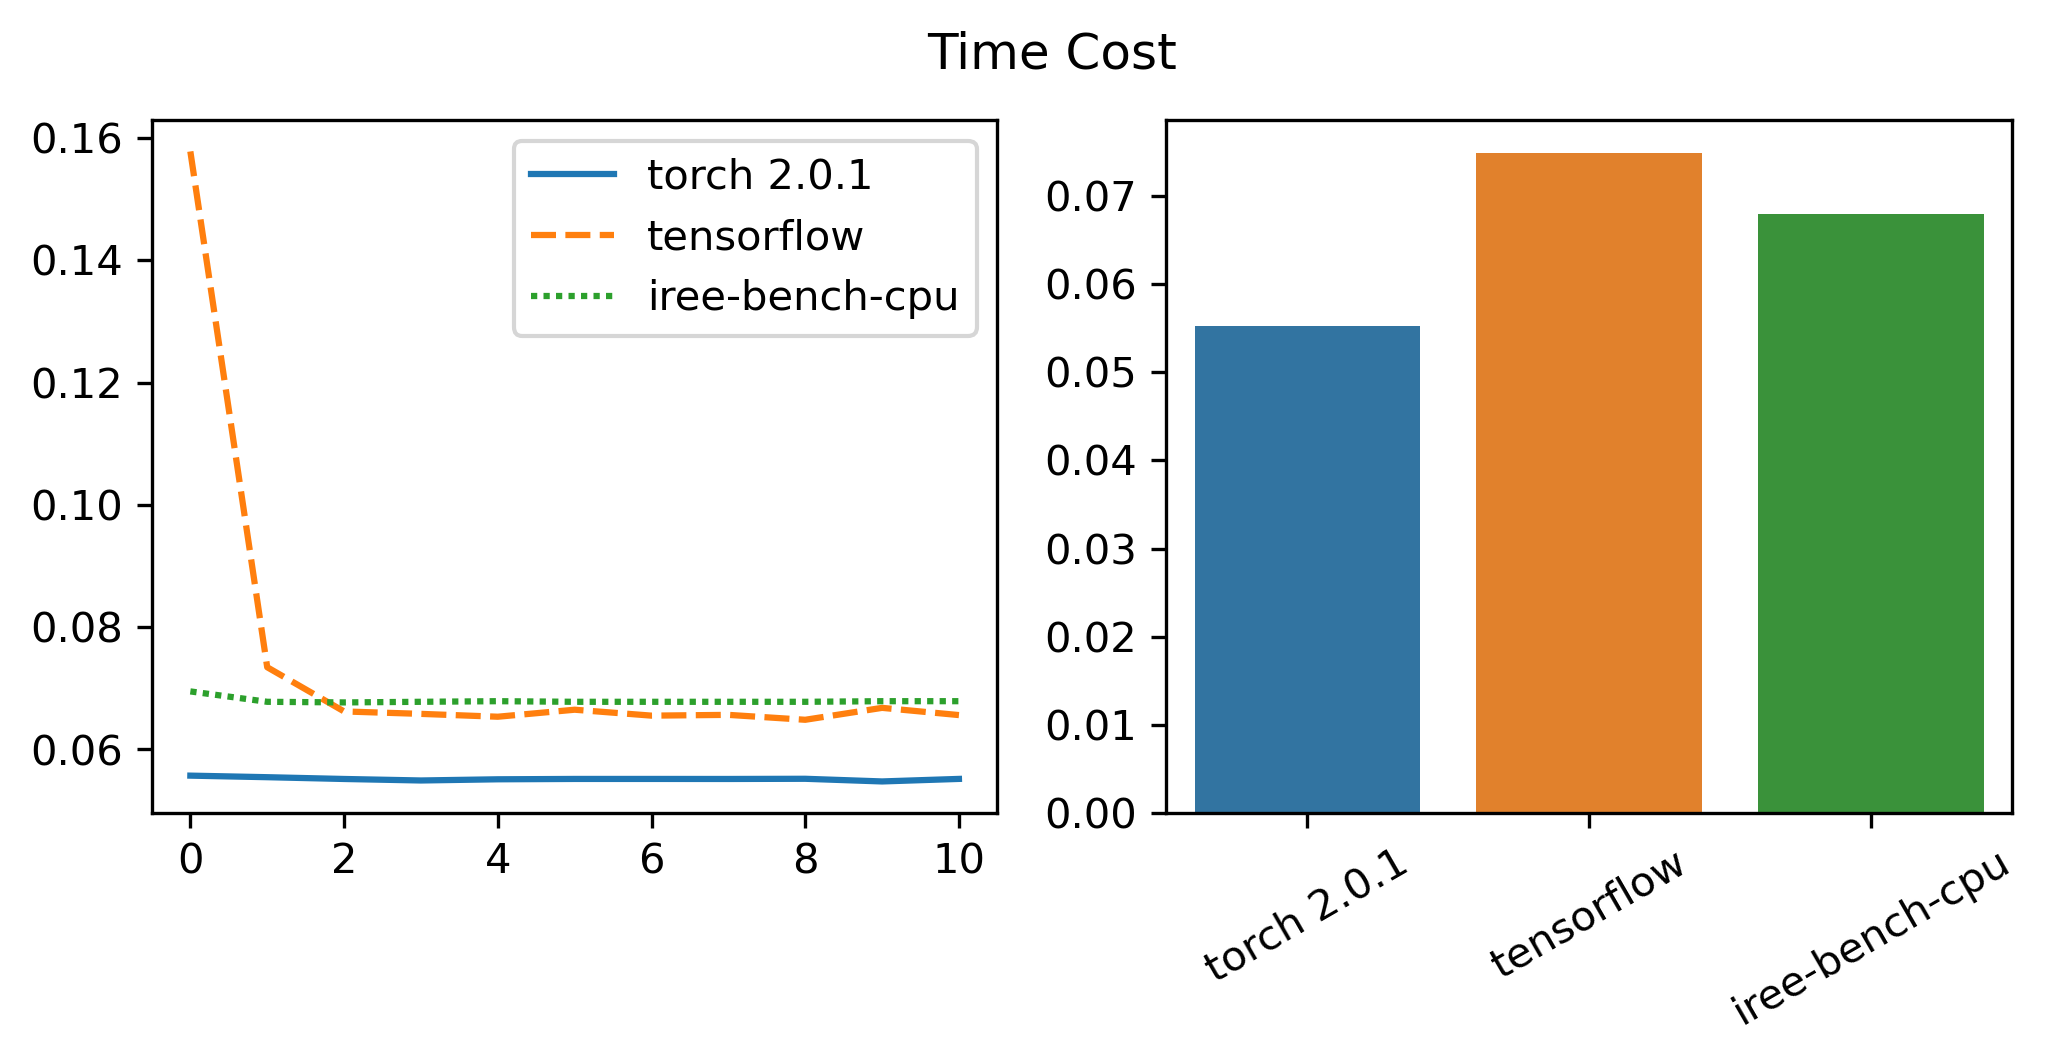

In [3]:
from functools import wraps
from time import perf_counter
from collections import namedtuple
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# to compile CPU version IREE-system kernel, just change 'cuda' to 'llvm-cpu'
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb.cpu \
--iree-hal-target-backends=llvm-cpu \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH} \
--iree-llvmcpu-debug-symbols=false \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf

# convert "100 ms" to 100.0
def destringify(time_str, unit='ms'):
    # 移除字符串中的 ' ms'，然后将剩余部分转换为浮点数
    if 'ms' in time_str:
        time_in_us = 1000.0*float(time_str.replace(' ms', ''))
    elif 'us' in time_str:
        time_in_us = float(time_str.replace(' us', ''))
    elif 's' in time_str:
        time_in_us = 1000000.0*float(time_str.replace(' us', ''))
    if unit == 'us':
        return time_in_us
    elif unit == 'ms':
        return time_in_us*0.001
    elif unit == 's':
        return time_in_us*0.000001

def torch_benchmark(repetitions):
    import torch.utils.benchmark as benchmark
    lhs_data = np.random.randn(1026, 2556).astype(np.float32)
    rhs_data = np.random.randn(2556, 1026).astype(np.float32)
    #TODO: move this into ragdoll.utils.get_gpu_device
    device = torch.device("cpu")
    lhs, rhs = [torch.from_numpy(i).to(device) for i in [lhs_data, rhs_data]]
    timer = benchmark.Timer(
        stmt='torch.matmul(lhs, rhs)',
        globals={'lhs': lhs, 'rhs': rhs}
    )
    
    # 运行基准测试并打印结果
    result = []
    for i in range(repetitions):
        result+=timer.timeit(REPETITIONS_PER_LAUNCH).times  # 例如，这里我们重复测试 100 次
    
    return result
    
def tensorflow_benchmark(repetitions):
    import tensorflow as tf

    # 强制 TensorFlow 使用 GPU（假设你的系统中有可用的 GPU）
    cpus = tf.config.experimental.list_physical_devices('CPU')
    
    # 创建随机数据张量
    lhs_data = tf.random.normal([1026, 2556], dtype=tf.float32)
    rhs_data = tf.random.normal([2556, 1026], dtype=tf.float32)
    
    # 使用 tf.function 将矩阵乘法操作编译成图
    @tf.function
    def matmul_operation(lhs, rhs):
        with tf.device('/CPU:0'):
            return tf.matmul(lhs, rhs)
    import time
    results = []
    for _ in range(repetitions):
        start_time = time.time()
        for _a in range(REPETITIONS_PER_LAUNCH):
            _ = matmul_operation(lhs_data, rhs_data)
        end_time = time.time()
        avg_time = (end_time - start_time)
        results.append(avg_time)
    return results

def ragdoll_benchmark(repetitions, optimised=False):
    if optimised:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.bench.vmfb.cpu"
    else:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb.cpu"
    config = iree.runtime.system_api.Config("local-task")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
        binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    input_data = ["1026x2556xf32", "2556x1026xf32"]
    
    def forward():
        return iree.runtime.benchmark_module(
            vmm, 
            entry_function="matmul", 
            inputs=input_data, 
            device="local-task", 
            batch_size=REPETITIONS_PER_LAUNCH, 
            benchmark_repetitions=repetitions,
            batch_concurrency=1,
            benchmark_min_time="1s", 
            print_statistics=False
        )
    
    bench_result = forward()
    if repetitions > 1:
        forward_timecost = [destringify(measure.time, unit='s') for measure in bench_result[0:-4]]
    else:
        forward_timecost = [destringify(bench_result[0].time, unit='s')]
    return forward_timecost

def benchmark_entry(repetitions=1):
    iree_bench = ragdoll_benchmark(repetitions)
    torch_bench = torch_benchmark(repetitions)
    tf_bench = tensorflow_benchmark(repetitions)
    #ragdoll_bench = ragdoll_benchmark(repetitions, optimised=True)
    return np.array(torch_bench), np.array(tf_bench), np.array(iree_bench)
    
names = ["torch 2.0.1", "tensorflow", "iree-bench-cpu"]
results = benchmark_entry(11)
forward_line = pd.DataFrame(dict(zip(names, [res for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
plt.suptitle("Time Cost")

In [4]:
print(results)

(array([0.05572345, 0.05546808, 0.0551771 , 0.05493138, 0.0551255 ,
       0.05518255, 0.05518259, 0.05517724, 0.05520835, 0.05477376,
       0.05518877]), array([0.15781641, 0.07345414, 0.06622314, 0.06582522, 0.06535864,
       0.06650615, 0.0655365 , 0.06566334, 0.06485915, 0.06680942,
       0.06562734]), array([0.0695, 0.0678, 0.0677, 0.0678, 0.0679, 0.0678, 0.0678, 0.0678,
       0.0678, 0.0679, 0.0679]))


## Remark
Above tutorial shown how to handcraft benchmarks for pytorch and IREE platform
However, we wrapped all these utils in ragdoll project, so just use simplified APIs for convenience
in production